
## CS 432 Databases — Course Project Report

---

### Video Demonstration : https://drive.google.com/file/d/1QM8AQvYB7yuoPPMKjK_0YnkT7UAqC0oM/view?usp=drive_link

---

## Table of Contents
1. [Introduction](#1-introduction)
2. [Implementation Overview](#2-implementation-overview)
3. [B+ Tree Operations Demo](#3-b-tree-operations-demo)
4. [Tree Visualisation](#4-tree-visualisation)
5. [Database Manager Demo](#5-database-manager-demo)
6. [Performance Analysis](#6-performance-analysis)
7. [Conclusion](#7-conclusion)


## 0. Setup — Imports & Path Configuration

In [3]:
import sys, os, random, time, tracemalloc, warnings
warnings.filterwarnings('ignore')

# Add the database package to the Python path
DB_PATH = os.path.join(os.getcwd(), 'database')
if DB_PATH not in sys.path:
    sys.path.insert(0, DB_PATH)

from bplustree   import BPlusTree, BPlusTreeNode
from table       import Table
from db_manager  import DatabaseManager
from bruteforce  import BruteForceDB
from performance import PerformanceAnalyzer
import inspect
from bplustree import BPlusTree

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print("All imports successful ")


All imports successful 


---
## 1. Introduction

### Problem Statement

Modern database management systems face the fundamental challenge of efficiently
storing and retrieving large volumes of data. A naive approach (linear scan through
unsorted records) has **O(n)** complexity for every operation, which becomes
prohibitively slow as datasets grow.

### Proposed Solution: B+ Tree Indexing

A **B+ Tree** is a self-balancing, ordered tree structure that solves this problem
by guaranteeing **O(log n)** time for search, insertion, and deletion. Its key
architectural advantages are:

| Feature | Benefit |
|---|---|
| Balanced height | Consistent O(log n) depth for all operations |
| High branching factor (order *m*) | Fewer disk I/Os in practice |
| Leaf linked list | O(log n + k) range queries |
| Values stored only in leaves | Internal nodes act as pure routing indices |

### Project Scope

This project implements:
- A complete **B+ Tree** from scratch (insertion, deletion, search, range query, update)
- A **Table** abstraction with schema validation, backed by the B+ Tree
- A **DatabaseManager** supporting multiple databases and tables
- A **BruteForceDB** linear baseline for performance comparison
- Automated **benchmarking** and **Graphviz visualisation**


---
## 2. Implementation Overview

### File Structure

```
db_management_system/
├── database/
│   ├── __init__.py      
│   ├── bplustree.py       
│   ├── table.py           
│   ├── db_manager.py      
│   ├── bruteforce.py          
│   └── performance.py         
├── report.ipynb        
└── requirements.txt
```

### B+ Tree — Key Design Decisions

**Node capacity:** For a tree of order *m*, each node holds at most *m − 1* keys
and at most *m* children. Non-root nodes maintain at least ⌈*m*/2⌉ − 1 keys.

**Insertion** uses a *proactive split* strategy: before descending into a full child,
the child is split. This guarantees that when a leaf is reached it always has space.

**Deletion** uses a *proactive fill* strategy: before descending into a deficient
child (keys ≤ min_keys), the child borrows from a sibling or merges. This avoids
a second traversal back up the tree.

**Leaf linked list:** All leaf nodes are chained via `next` pointers. Range queries
navigate to the start leaf in O(log n) and then walk the chain in O(k).


---
## 3. B+ Tree Operations Demo

### 3.1 Insertion


In [206]:
# ── Create a B+ Tree of order 4 (max 3 keys per node) ──
tree = BPlusTree(order=4)

insert_keys = [10, 20, 5, 6, 12, 30, 7, 17, 3, 25, 14, 28]
for k in insert_keys:
    tree.insert(k, f"record_{k}")

print(f"Tree: {tree}")
print(f"  Inserted keys (sorted): {[k for k,_ in tree.get_all()]}")
print(f"  Height: {tree.height()}")
print(f"  Size  : {len(tree)}")


Tree: BPlusTree(order=4, size=12, height=3)
  Inserted keys (sorted): [3, 5, 6, 7, 10, 12, 14, 17, 20, 25, 28, 30]
  Height: 3
  Size  : 12


### 3.2 Search

In [207]:
# Exact match search
for key in [6, 30, 99]:
    result = tree.search(key)
    status = f"Found → {result}" if result else "NOT FOUND"
    print(f"  search({key:>3}) : {status}")


  search(  6) : Found → record_6
  search( 30) : Found → record_30
  search( 99) : NOT FOUND


### 3.3 Range Query

In [208]:
results = tree.range_query(6, 20)
print("Range query [6 … 20]:")
for k, v in results:
    print(f"  {k} → {v}")
print(f"  Total results: {len(results)}")


Range query [6 … 20]:
  6 → record_6
  7 → record_7
  10 → record_10
  12 → record_12
  14 → record_14
  17 → record_17
  20 → record_20
  Total results: 7


### 3.4 Update

In [209]:
print(f"Before update: tree.search(10) = {tree.search(10)}")
success = tree.update(10, "UPDATED_record_10")
print(f"Update returned: {success}")
print(f"After  update: tree.search(10) = {tree.search(10)}")


Before update: tree.search(10) = record_10
Update returned: True
After  update: tree.search(10) = UPDATED_record_10


### 3.5 Deletion

In [210]:
print("Before deletion:", [k for k,_ in tree.get_all()])

for del_key in [6, 17, 30, 5]:
    tree.delete(del_key)
    print(f"  Deleted {del_key}: remaining = {[k for k,_ in tree.get_all()]}")

print(f"\nFinal tree height: {tree.height()}, size: {len(tree)}")


Before deletion: [3, 5, 6, 7, 10, 12, 14, 17, 20, 25, 28, 30]
  Deleted 6: remaining = [3, 5, 7, 10, 12, 14, 17, 20, 25, 28, 30]
  Deleted 17: remaining = [3, 5, 7, 10, 12, 14, 20, 25, 28, 30]
  Deleted 30: remaining = [3, 5, 7, 10, 12, 14, 20, 25, 28]
  Deleted 5: remaining = [3, 7, 10, 12, 14, 20, 25, 28]

Final tree height: 3, size: 8


### 3.6 Linked-list leaf traversal

In [211]:
# Walk the leaf chain manually to confirm linkage is intact
t = BPlusTree(order=4)
for k in range(1, 16):
    t.insert(k, k * 10)

node = t.root
while not node.is_leaf:
    node = node.children[0]        # Go to leftmost leaf

print("Leaf chain:")
chain_no = 0
while node:
    print(f"  Leaf {chain_no}: keys={node.keys}  →  {'next' if node.next else 'None'}")
    chain_no += 1
    node = node.next


Leaf chain:
  Leaf 0: keys=[1, 2]  →  next
  Leaf 1: keys=[3, 4]  →  next
  Leaf 2: keys=[5, 6]  →  next
  Leaf 3: keys=[7, 8]  →  next
  Leaf 4: keys=[9, 10]  →  next
  Leaf 5: keys=[11, 12]  →  next
  Leaf 6: keys=[13, 14, 15]  →  None


---
## 4. Tree Visualisation

We use Graphviz to render the tree structure.
- **Yellow nodes** = internal nodes (routing only)
- **Blue nodes** = leaf nodes (store actual data)
- **Dashed blue arrows** = leaf linked-list (next pointers)


Visualisation tree: BPlusTree(order=4, size=15, height=3)


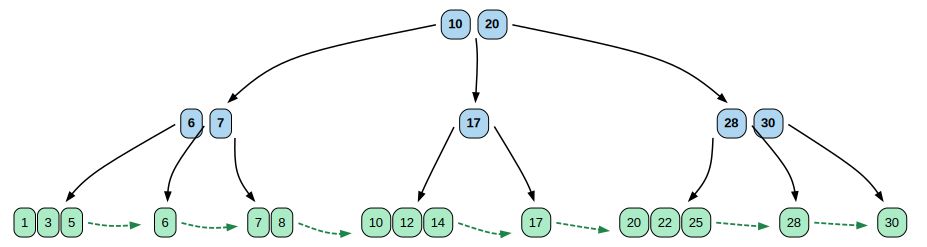

In [ ]:
# Build a clean tree for visualisation (order=4)
viz_tree = BPlusTree(order=4)
for k in [10, 20, 5, 6, 12, 30, 7, 17, 3, 25, 14, 28, 1, 8, 22]:
    viz_tree.insert(k, f"v{k}")

print(f"Visualisation tree: {viz_tree}")
dot = viz_tree.visualize_tree()
dot          # Renders inline in Jupyter


Larger tree (order=6, 30 keys): BPlusTree(order=6, size=30, height=3)


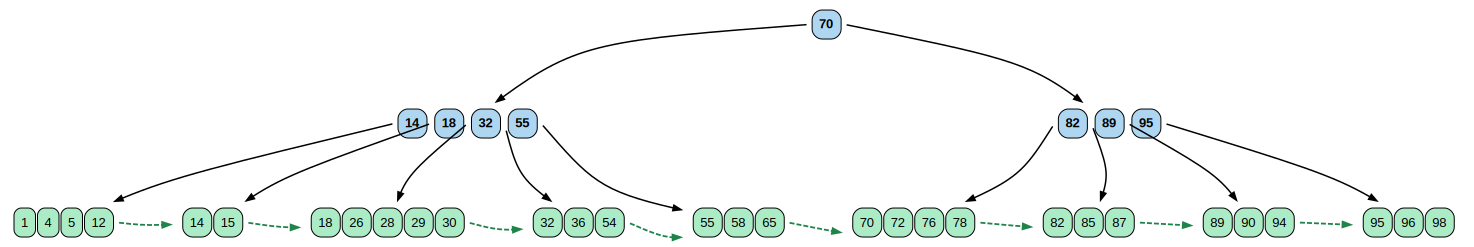

In [213]:
# Visualise a larger tree (order=6)
big_tree = BPlusTree(order=6)
import random; random.seed(42)
for k in random.sample(range(1, 101), 30):
    big_tree.insert(k, k)
print(f"Larger tree (order=6, 30 keys): {big_tree}")
dot2 = big_tree.visualize_tree()
dot2


Before deletions: [1, 3, 5, 6, 7, 8, 10, 12, 14, 17, 20, 22, 25, 28, 30]
After  deletions: [1, 3, 6, 7, 8, 10, 12, 14, 22, 25, 28, 30]


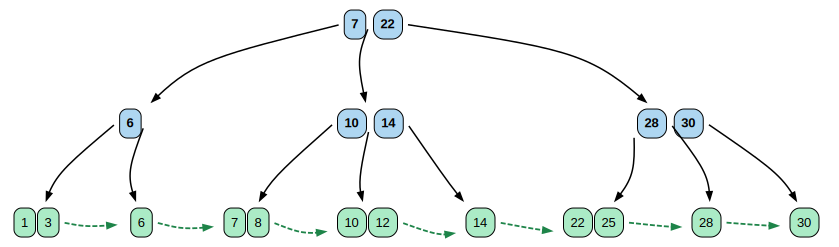

In [ ]:
# Show tree BEFORE and the state AFTER several deletions
before_keys = [k for k,_ in viz_tree.get_all()]
print("Before deletions:", before_keys)
for dk in [20, 5, 17]:
    viz_tree.delete(dk)
after_keys = [k for k,_ in viz_tree.get_all()]
print("After  deletions:", after_keys)

dot3 = viz_tree.visualize_tree()
dot3


---
## 5. Database Manager Demo — **fixiit_db**

We recreate the **FixIIT** facility-management database inside our custom DBMS.
The schema mirrors the MySQL `fixiit_db` exactly — nine tables, all indexed by
B+ Trees.

| Table | Search Key | Records |
|---|---|---|
| `roles` | `role_id` | 11 |
| `statuses` | `status_id` | 10 |
| `categories` | `category_id` | 10 |
| `locations` | `location_id` | 13 |
| `members` | `member_id` | 29 |
| `member_roles` | `id` | 13 |
| `tickets` | `ticket_id` | 20 |
| `assignments` | `assignment_id` | 10 |
| `feedback` | `feedback_id` | 10 |


In [215]:
mgr = DatabaseManager()
mgr.create_database("fixiit_db")

mgr.create_table("fixiit_db","roles",
    schema={"role_id":"int","role_name":"str","role_code":"str"},
    search_key="role_id",order=8)
mgr.create_table("fixiit_db","statuses",
    schema={"status_id":"int","status_name":"str","is_closed":"int","sort_order":"int"},
    search_key="status_id",order=8)
mgr.create_table("fixiit_db","categories",
    schema={"category_id":"int","category_name":"str","sla_hours":"int","is_active":"int"},
    search_key="category_id",order=8)
mgr.create_table("fixiit_db","locations",
    schema={"location_id":"int","building_name":"str","floor_number":"int",
            "room_number":"str","type":"str"},
    search_key="location_id",order=8)
mgr.create_table("fixiit_db","members",
    schema={"member_id":"int","name":"str","age":"int","email":"str",
            "contact_number":"str","address":"str"},
    search_key="member_id",order=8)
mgr.create_table("fixiit_db","member_roles",
    schema={"id":"int","member_id":"int","role_id":"int",
            "assigned_date":"str","assigned_by_member_id":"int"},
    search_key="id",order=8)
mgr.create_table("fixiit_db","tickets",
    schema={"ticket_id":"int","title":"str","member_id":"int","location_id":"int",
            "category_id":"int","priority":"str","status_id":"int",
            "created_at":"str","updated_at":"str"},
    search_key="ticket_id",order=8)
mgr.create_table("fixiit_db","assignments",
    schema={"assignment_id":"int","ticket_id":"int","technician_member_id":"int",
            "assigned_by":"int","assigned_at":"str","instructions":"str"},
    search_key="assignment_id",order=8)
mgr.create_table("fixiit_db","feedback",
    schema={"feedback_id":"int","ticket_id":"int","rating":"int",
            "comment":"str","submitted_by_member_id":"int","submitted_at":"str"},
    search_key="feedback_id",order=8)

print("fixiit_db created:")
mgr.describe("fixiit_db")


[OK] Database 'fixiit_db' created.
[OK] Table 'roles' created in 'fixiit_db' (order=8, search_key='role_id').
[OK] Table 'statuses' created in 'fixiit_db' (order=8, search_key='status_id').
[OK] Table 'categories' created in 'fixiit_db' (order=8, search_key='category_id').
[OK] Table 'locations' created in 'fixiit_db' (order=8, search_key='location_id').
[OK] Table 'members' created in 'fixiit_db' (order=8, search_key='member_id').
[OK] Table 'member_roles' created in 'fixiit_db' (order=8, search_key='id').
[OK] Table 'tickets' created in 'fixiit_db' (order=8, search_key='ticket_id').
[OK] Table 'assignments' created in 'fixiit_db' (order=8, search_key='assignment_id').
[OK] Table 'feedback' created in 'fixiit_db' (order=8, search_key='feedback_id').
fixiit_db created:
Database: fixiit_db  (9 table(s))
  └─ roles  rows=0  schema={'role_id': 'int', 'role_name': 'str', 'role_code': 'str'}  key='role_id'
  └─ statuses  rows=0  schema={'status_id': 'int', 'status_name': 'str', 'is_closed':

In [216]:
roles_tbl = mgr.get_table("fixiit_db","roles")
for rid,rname,rcode in [
    (1,"Admin","ADMIN"),(2,"Supervisor","SUPERVISOR"),
    (3,"Fire & Safety Officer","FIRE_SAFETY"),(4,"AC Technician","AC_TECH"),
    (5,"Electrician","ELECTRIC"),(6,"Plumber","PLUMB"),
    (7,"IT Support","IT_SUPPORT"),(8,"Carpenter","CARP"),
    (9,"Civil Maintenance","CIVIL"),(10,"Housekeeping","HOUSE"),
    (11,"Pest Control","PEST"),
]:
    roles_tbl.insert({"role_id":rid,"role_name":rname,"role_code":rcode})
print(f"roles        : {roles_tbl.count()} rows")

st_tbl = mgr.get_table("fixiit_db","statuses")
for sid,sname,ic,so in [
    (1,"Open",0,1),(2,"Assigned",0,2),(3,"In_Progress",0,3),(4,"On_Hold",0,4),
    (5,"Closed",1,5),(6,"Resolved",1,6),(7,"Cancelled",1,7),(8,"Reopened",0,8),
    (9,"Waiting_Parts",0,9),(10,"Scheduled",0,10),
]:
    st_tbl.insert({"status_id":sid,"status_name":sname,"is_closed":ic,"sort_order":so})
print(f"statuses     : {st_tbl.count()} rows")

cat_tbl = mgr.get_table("fixiit_db","categories")
for cid,cname,sla,ia in [
    (1,"Electrical",24,1),(2,"Plumbing",24,1),(3,"Air Conditioning",48,1),
    (4,"Carpentry",72,1),(5,"IT Support",24,1),(6,"Housekeeping",12,1),
    (7,"General Maintenance",48,1),(8,"Pest Control",72,1),
    (9,"Fire & Safety",24,1),(10,"Civil Maintenance",96,1),
]:
    cat_tbl.insert({"category_id":cid,"category_name":cname,"sla_hours":sla,"is_active":ia})
print(f"categories   : {cat_tbl.count()} rows")


roles        : 11 rows
statuses     : 10 rows
categories   : 10 rows


In [217]:
loc_tbl = mgr.get_table("fixiit_db","locations")
for lid,bldg,flr,room,typ in [
    (1,"Academic Block 7",1,"AB7/201","Classroom"),
    (2,"Academic Block 4",2,"AB4/305","Laboratory"),
    (3,"Academic Block 6",1,"AB6/106","Workshop"),
    (4,"Academic Block 10",0,"AB10/104","Lab"),
    (5,"Library",1,"L205","Conference Room 1"),
    (6,"Library",1,"L201","Reading Area"),
    (7,"Academic Block 3",0,"AB3/102","Student Affairs Office"),
    (8,"Hostel Jurqia",1,"J231W","Washroom"),
    (9,"Hostel Kyzeel",2,"K335","Common Room"),
    (10,"2D Cafe",1,"AB1","Outlet"),
    (11,"Sports Complex",1,"S05","Gym"),
    (12,"Central Arcade",1,"CA201W","Washroom"),
    (13,"Hostel Jurqia",2,"J337","Room"),
]:
    loc_tbl.insert({"location_id":lid,"building_name":bldg,
                    "floor_number":flr,"room_number":room,"type":typ})
print(f"locations    : {loc_tbl.count()} rows")

mem_tbl = mgr.get_table("fixiit_db","members")
for row in [
    (1,"Prof. XYZ",37,"prof.xyz@iitgn.ac.in","+91 9123456789","AB 3/302A"),
    (2,"Shiv Patel",20,"shiv.patel@iitgn.ac.in","+91 8123406789","J307"),
    (3,"Prof. ABC",42,"prof.abc@iitgn.ac.in","+91 7123456190","AB 5/301A"),
    (4,"Shivansh",21,"shivansh@iitgn.ac.in","+91 6123456729","J235"),
    (5,"Abhishek",20,"abhishek@iitgn.ac.in","+91 9123456739","L105"),
    (6,"Farhan Obaid",22,"farhan.obaid@iitgn.ac.in","+91 9123456749","J236"),
    (7,"Student A",24,"student.a@iitgn.ac.in","+91 9123456759","A123"),
    (8,"Arin Mehta",20,"arin.mehta@iitgn.ac.in","+91 9123456788","J235"),
    (9,"Soham",20,"soham@iitgn.ac.in","+91 9123456769","Library Conference Room 1"),
    (10,"Abhinav",21,"abhinav@iitgn.ac.in","+91 9123056739","L115"),
    (11,"Student B",23,"student.b@iitgn.ac.in","+91 9123456791","K431"),
    (12,"Attendant A",33,"library.attendant.a@iitgn.ac.in","+91 9123456792","Library, Office 2"),
    (13,"Jiya",26,"jiya@iitgn.ac.in","+91 9123456793","I344"),
    (14,"Dilip Singh",24,"dilip.singh@iitgn.ac.in","+91 9123456794","Sports Complex, Gym"),
    (15,"Attendant B",27,"library.attendant.b@iitgn.ac.in","+91 9123456795","Library, Office 3"),
    (16,"Dean, SA",28,"dean.sa@iitgn.ac.in","+91 9123456796","AB 3/102"),
    (17,"Electrician A",32,"electrician.a@fixiit.iitgn.ac.in","+91 9000000001","IITGN Maintenance Office"),
    (18,"Electrician B",29,"electrician.b@fixiit.iitgn.ac.in","+91 9000000002","IITGN Maintenance Office"),
    (19,"Plumber A",35,"plumber.a@fixiit.iitgn.ac.in","+91 9000000003","IITGN Maintenance Office"),
    (20,"Plumber B",31,"plumber.b@fixiit.iitgn.ac.in","+91 9000000004","IITGN Maintenance Office"),
    (21,"AC Technician A",30,"ac.tech.a@fixiit.iitgn.ac.in","+91 9000000005","IITGN Maintenance Office"),
    (22,"IT Support A",27,"it.support.a@fixiit.iitgn.ac.in","+91 9000000006","IITGN IT Helpdesk"),
    (23,"Carpenter A",38,"carpenter.a@fixiit.iitgn.ac.in","+91 9000000007","IITGN Maintenance Office"),
    (24,"Housekeeping A",33,"housekeeping.a@fixiit.iitgn.ac.in","+91 9000000008","IITGN Housekeeping Office"),
    (25,"Civil Technician A",36,"civil.tech.a@fixiit.iitgn.ac.in","+91 9000000009","IITGN Maintenance Office"),
    (26,"Fire & Safety Officer A",34,"fire.safety.a@fixiit.iitgn.ac.in","+91 9000000010","IITGN Safety Office"),
    (27,"Pest Control A",31,"pest.control.a@fixiit.iitgn.ac.in","+91 9000000011","IITGN Maintenance Office"),
    (28,"Hostel Office",40,"hostel.office@fixiit.iitgn.ac.in","+91 9000000012","Hostel Administration Office"),
    (29,"Hostel Caretaker",45,"hostel.caretaker@fixiit.iitgn.ac.in","+91 9000000013","Hostel Administration Office"),
]:
    mem_tbl.insert({"member_id":row[0],"name":row[1],"age":row[2],
                    "email":row[3],"contact_number":row[4],"address":row[5]})
print(f"members      : {mem_tbl.count()} rows")


locations    : 13 rows
members      : 29 rows


In [218]:
mr_tbl = mgr.get_table("fixiit_db","member_roles")
for row in [
    (1,28,1,"2025-08-01",28),(2,29,2,"2025-08-01",28),(3,26,3,"2025-08-02",29),
    (4,21,4,"2025-08-02",29),(5,17,5,"2025-08-02",29),(6,18,5,"2025-08-02",29),
    (7,19,6,"2025-08-02",29),(8,20,6,"2025-08-02",29),(9,22,7,"2025-08-02",29),
    (10,23,8,"2025-08-02",29),(11,25,9,"2025-08-02",29),
    (12,24,10,"2025-08-02",29),(13,27,11,"2025-08-02",29),
]:
    mr_tbl.insert({"id":row[0],"member_id":row[1],"role_id":row[2],
                   "assigned_date":row[3],"assigned_by_member_id":row[4]})
print(f"member_roles : {mr_tbl.count()} rows")

tkt_tbl = mgr.get_table("fixiit_db","tickets")
for row in [
    (1,"Projector not working",3,1,1,"Medium",5,"2026-01-10 09:00:00","2026-01-10 09:00:00"),
    (2,"Leaky faucet in Hostel Jurqia",8,8,2,"High",5,"2026-01-11 08:30:00","2026-01-11 08:45:00"),
    (3,"Broken window latch",15,9,10,"Medium",5,"2026-01-12 10:15:00","2026-01-12 10:15:00"),
    (4,"WiFi not working in library",9,5,5,"Urgent",5,"2026-01-13 14:20:00","2026-01-13 14:20:00"),
    (5,"Gym locker jammed",14,11,4,"Urgent",5,"2026-01-14 16:05:00","2026-01-14 16:05:00"),
    (6,"AC not working in Lab",4,2,3,"High",5,"2026-01-15 09:10:00","2026-01-15 11:00:00"),
    (7,"Power outlet sparks",5,3,1,"Emergency",2,"2026-01-15 12:30:00","2026-01-15 13:00:00"),
    (8,"Clogged drain in cafeteria",10,10,2,"High",2,"2026-01-16 07:45:00","2026-01-16 09:00:00"),
    (9,"Network switch reboot loop",9,4,5,"Urgent",2,"2026-01-16 10:20:00","2026-01-16 11:10:00"),
    (10,"Broken chair in classroom",7,1,4,"Medium",2,"2026-01-17 08:05:00","2026-01-17 08:30:00"),
    (11,"Ceiling fan noise",6,7,1,"Medium",3,"2026-01-18 09:40:00","2026-01-19 10:00:00"),
    (12,"Water geyser issue",8,8,2,"Emergency",3,"2026-01-19 07:15:00","2026-01-20 12:00:00"),
    (13,"Desk repair in library",12,6,4,"Low",3,"2026-01-20 13:00:00","2026-01-21 09:30:00"),
    (14,"Floor cleaning spill",11,10,6,"Urgent",3,"2026-01-21 18:10:00","2026-01-22 08:00:00"),
    (15,"Replace lab UPS battery",13,2,1,"High",4,"2026-01-22 10:50:00","2026-01-23 11:00:00"),
    (16,"Security camera offline",16,7,5,"Urgent",4,"2026-01-23 15:05:00","2026-01-24 10:30:00"),
    (17,"AC water leakage",4,13,3,"High",5,"2026-01-05 09:00:00","2026-01-06 16:00:00"),
    (18,"Broken door handle",11,9,10,"Low",5,"2026-01-06 11:00:00","2026-01-07 14:30:00"),
    (19,"WiFi not discoverable",12,6,5,"Medium",5,"2026-01-07 08:00:00","2026-01-07 17:00:00"),
    (20,"Washroom odor issue",10,12,6,"Medium",5,"2026-01-08 07:45:00","2026-01-08 12:00:00"),
]:
    tkt_tbl.insert({"ticket_id":row[0],"title":row[1],"member_id":row[2],
                    "location_id":row[3],"category_id":row[4],"priority":row[5],
                    "status_id":row[6],"created_at":row[7],"updated_at":row[8]})
print(f"tickets      : {tkt_tbl.count()} rows")


member_roles : 13 rows
tickets      : 20 rows


In [219]:
asgn_tbl = mgr.get_table("fixiit_db","assignments")
for row in [
    (1,7,17,28,"2026-01-15 13:05:00","Inspect wiring and replace damaged outlet."),
    (2,8,19,29,"2026-01-16 09:10:00","Clear blockage and test drainage flow."),
    (3,9,22,29,"2026-01-16 11:15:00","Diagnose switch loop and apply firmware update."),
    (4,10,23,29,"2026-01-17 08:35:00","Repair chair frame and reinforce joints."),
    (5,11,17,29,"2026-01-18 10:00:00","Inspect fan mounts and balance blades."),
    (6,12,19,28,"2026-01-19 08:00:00","Check heater coils and replace thermostat."),
    (7,13,23,29,"2026-01-20 13:30:00","Sand and refinish desk edge."),
    (8,14,24,29,"2026-01-21 18:20:00","Deep clean and apply floor polish."),
    (9,15,17,29,"2026-01-22 11:10:00","Source compatible battery and schedule swap."),
    (10,16,22,29,"2026-01-23 15:15:00","Verify power, reset camera, and check network."),
]:
    asgn_tbl.insert({"assignment_id":row[0],"ticket_id":row[1],
                     "technician_member_id":row[2],"assigned_by":row[3],
                     "assigned_at":row[4],"instructions":row[5]})
print(f"assignments  : {asgn_tbl.count()} rows")

fb_tbl = mgr.get_table("fixiit_db","feedback")
for row in [
    (1,17,5,"Cooling restored quickly.",4,"2026-01-06 17:00:00"),
    (2,18,4,"Handle replaced and door works.",11,"2026-01-07 15:00:00"),
    (3,19,5,"Network stable after update.",12,"2026-01-07 18:00:00"),
    (4,20,3,"Odor reduced, need follow-up.",10,"2026-01-08 12:30:00"),
    (5,1,4,"Projector repaired successfully.",3,"2026-01-11 10:00:00"),
    (6,2,5,"Faucet fixed quickly.",8,"2026-01-11 09:30:00"),
    (7,3,4,"Window latch replaced.",15,"2026-01-12 15:00:00"),
    (8,4,5,"WiFi restored in reading room.",9,"2026-01-13 18:00:00"),
    (9,5,3,"Locker repaired but slightly tight.",14,"2026-01-14 17:00:00"),
    (10,6,5,"AC cooling properly now.",4,"2026-01-15 16:00:00"),
]:
    fb_tbl.insert({"feedback_id":row[0],"ticket_id":row[1],"rating":row[2],
                   "comment":row[3],"submitted_by_member_id":row[4],"submitted_at":row[5]})
print(f"feedback     : {fb_tbl.count()} rows")

print("\n── fixiit_db fully loaded ──")
mgr.describe("fixiit_db")


assignments  : 10 rows
feedback     : 10 rows

── fixiit_db fully loaded ──
Database: fixiit_db  (9 table(s))
  └─ roles  rows=11  schema={'role_id': 'int', 'role_name': 'str', 'role_code': 'str'}  key='role_id'
  └─ statuses  rows=10  schema={'status_id': 'int', 'status_name': 'str', 'is_closed': 'int', 'sort_order': 'int'}  key='status_id'
  └─ categories  rows=10  schema={'category_id': 'int', 'category_name': 'str', 'sla_hours': 'int', 'is_active': 'int'}  key='category_id'
  └─ locations  rows=13  schema={'location_id': 'int', 'building_name': 'str', 'floor_number': 'int', 'room_number': 'str', 'type': 'str'}  key='location_id'
  └─ members  rows=29  schema={'member_id': 'int', 'name': 'str', 'age': 'int', 'email': 'str', 'contact_number': 'str', 'address': 'str'}  key='member_id'
  └─ member_roles  rows=13  schema={'id': 'int', 'member_id': 'int', 'role_id': 'int', 'assigned_date': 'str', 'assigned_by_member_id': 'int'}  key='id'
  └─ tickets  rows=20  schema={'ticket_id': 'int',

### 5.3 Query Demonstrations

Demonstrating **GET**, **RANGE QUERY**,  **UPDATE**, and **DELETE**
across the fixiit_db tables.


In [220]:

print("  GET: Lookup ticket #9 (Network switch reboot loop)")

t = tkt_tbl.get(9)
cat  = cat_tbl.get(t["category_id"])
stat = st_tbl.get(t["status_id"])
loc  = loc_tbl.get(t["location_id"])
reporter = mem_tbl.get(t["member_id"])
print(f"  Title    : {t['title']}")
print(f"  Reporter : {reporter['name']} ({reporter['email']})")
print(f"  Category : {cat['category_name']}  (SLA {cat['sla_hours']} h)")
print(f"  Status   : {stat['status_name']}")
print(f"  Location : {loc['building_name']} — {loc['room_number']} ({loc['type']})")
print(f"  Priority : {t['priority']}")
print(f"  Created  : {t['created_at']}")


  GET: Lookup ticket #9 (Network switch reboot loop)
  Title    : Network switch reboot loop
  Reporter : Soham (soham@iitgn.ac.in)
  Category : IT Support  (SLA 24 h)
  Status   : Assigned
  Location : Academic Block 10 — AB10/104 (Lab)
  Priority : Urgent
  Created  : 2026-01-16 10:20:00


In [221]:

print(" RANGE QUERY: Tickets 5–12 with category & status")

print(f"{'ID':>3}  {'Title':<35} {'Priority':<12} {'Category':<18} {'Status'}")
print("-" * 92)
for tkt in tkt_tbl.range_query(5, 12):
    cat  = cat_tbl.get(tkt["category_id"])["category_name"]
    stat = st_tbl.get(tkt["status_id"])["status_name"]
    print(f"  {tkt['ticket_id']:>2}  {tkt['title']:<35} {tkt['priority']:<12} {cat:<18} {stat}")


 RANGE QUERY: Tickets 5–12 with category & status
 ID  Title                               Priority     Category           Status
--------------------------------------------------------------------------------------------
   5  Gym locker jammed                   Urgent       Carpentry          Closed
   6  AC not working in Lab               High         Air Conditioning   Closed
   7  Power outlet sparks                 Emergency    Electrical         Assigned
   8  Clogged drain in cafeteria          High         Plumbing           Assigned
   9  Network switch reboot loop          Urgent       IT Support         Assigned
  10  Broken chair in classroom           Medium       Carpentry          Assigned
  11  Ceiling fan noise                   Medium       Electrical         In_Progress
  12  Water geyser issue                  Emergency    Plumbing           In_Progress


In [222]:

print(" UPDATE")
before = tkt_tbl.get(10)
print(f"  BEFORE: priority={before['priority']:<8}  status={st_tbl.get(before['status_id'])['status_name']}")
updated = dict(before)
updated.update({"priority":"High","status_id":3,"updated_at":"2026-01-20 09:00:00"})
tkt_tbl.update(10, updated)
after = tkt_tbl.get(10)
print(f"  AFTER : priority={after['priority']:<8}  status={st_tbl.get(after['status_id'])['status_name']}")


 UPDATE
  BEFORE: priority=Medium    status=Assigned
  AFTER : priority=High      status=In_Progress


In [223]:

print(" DELETE: Remove feedback #4 (follow-up needed)")
print(f"  feedback rows BEFORE: {fb_tbl.count()}")
print(f"  Deleting: {fb_tbl.get(4)}")
fb_tbl.delete(4)
print(f"  feedback rows AFTER : {fb_tbl.count()}")
print(f"  fb_tbl.get(4) → {fb_tbl.get(4)}  ← None confirms deletion")


 DELETE: Remove feedback #4 (follow-up needed)
  feedback rows BEFORE: 10
  Deleting: {'feedback_id': 4, 'ticket_id': 20, 'rating': 3, 'comment': 'Odor reduced, need follow-up.', 'submitted_by_member_id': 10, 'submitted_at': '2026-01-08 12:30:00'}
  feedback rows AFTER : 9
  fb_tbl.get(4) → None  ← None confirms deletion


B+ Tree backing the 'tickets' table:
BPlusTree(order=8, size=20, height=2)


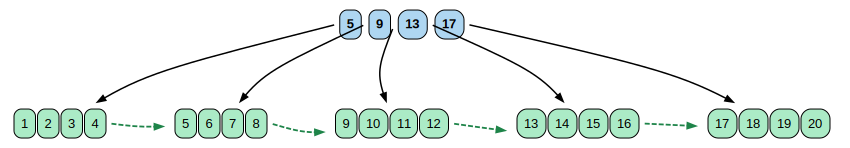

In [224]:
# Visualise the tickets B+ Tree
print("B+ Tree backing the 'tickets' table:")
print(tkt_tbl.data)
tkt_tbl.visualize()


B+ Tree backing the 'members' table:
BPlusTree(order=8, size=29, height=2)


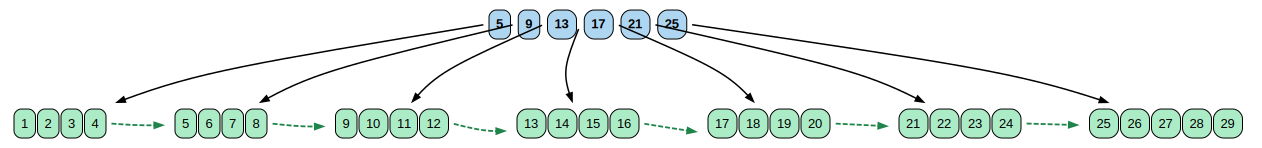

In [225]:
# Visualise the members B+ Tree
print("B+ Tree backing the 'members' table:")
print(mem_tbl.data)
mem_tbl.visualize()


---
## 6. Performance Analysis

We compare **B+ Tree** (order = 8) against **BruteForceDB** (unsorted list)
across six benchmarks.  Each benchmark is run over dataset sizes of
100 → 10 000 records.

### Why should B+ Tree win?

| Operation | B+ Tree | BruteForce |
|---|---|---|
| Search | O(log n) | O(n) |
| Insert | O(log n) | O(n) |
| Delete | O(log n) | O(n) |
| Range query | O(log n + k) | O(n log n) |
| Memory | Higher overhead | Lower overhead |


In [12]:
# Initialise and run all benchmarks
pa = PerformanceAnalyzer(
    sizes=[100, 500, 1000, 2000, 5000, 10000],
    seed=42,
    bpt_order=8,
)
results = pa.run_all(verbose=True)


  Performance Analysis  (B+ Tree order=8)

[1/6] Insertion benchmark …
  n=   100: BPT=   0.24 ms  BF=   0.30 ms
  n=   500: BPT=   2.13 ms  BF=   5.75 ms
  n=  1000: BPT=   2.94 ms  BF=  18.76 ms
  n=  2000: BPT=  11.03 ms  BF=  92.20 ms
  n=  5000: BPT=  13.60 ms  BF= 518.90 ms
  n= 10000: BPT= 136.57 ms  BF=2149.65 ms

[2/6] Search benchmark …
  n=   100: BPT=  0.173 ms  BF=  0.154 ms
  n=   500: BPT=  0.205 ms  BF=  0.933 ms
  n=  1000: BPT=  0.159 ms  BF=  1.799 ms
  n=  2000: BPT=  0.268 ms  BF=  4.212 ms
  n=  5000: BPT=  0.270 ms  BF= 10.039 ms
  n= 10000: BPT=  0.319 ms  BF= 22.654 ms

[3/6] Deletion benchmark …
  n=   100: BPT=   0.17 ms  BF=   0.07 ms
  n=   500: BPT=   0.31 ms  BF=   1.04 ms
  n=  1000: BPT=   0.74 ms  BF=   4.16 ms
  n=  2000: BPT=   1.82 ms  BF=  19.99 ms
  n=  5000: BPT=   5.07 ms  BF= 135.18 ms
  n= 10000: BPT=  11.16 ms  BF= 614.40 ms

[4/6] Range query benchmark …
  n=   100: BPT=   0.07 ms  BF=   0.21 ms
  n=   500: BPT=   0.29 ms  BF=   0.69 ms
  n=

In [13]:
# Print a formatted summary table
pa.summary_table()



Benchmark            n=100     n=500    n=1000    n=2000    n=5000   n=10000
insertion/B+ Tree                    0.24m     2.13m     2.94m    11.03m    13.60m   136.57m
insertion/BruteForce                 0.30m     5.75m    18.76m    92.20m   518.90m  2149.65m
search/B+ Tree                       0.17m     0.20m     0.16m     0.27m     0.27m     0.32m
search/BruteForce                    0.15m     0.93m     1.80m     4.21m    10.04m    22.65m
deletion/B+ Tree                     0.17m     0.31m     0.74m     1.82m     5.07m    11.16m
deletion/BruteForce                  0.07m     1.04m     4.16m    19.99m   135.18m   614.40m
range_query/B+ Tree                  0.07m     0.29m     0.50m     0.93m     2.57m     6.52m
range_query/BruteForce               0.21m     0.69m     2.10m     3.28m     9.50m    21.53m
memory/B+ Tree                       5.90K    46.00K    92.21K   192.96K   492.13K   989.07K
memory/BruteForce                    3.79K    35.02K    74.71K   152.18K   388.87K   

[OK] Performance plot saved to performance_comparison.png


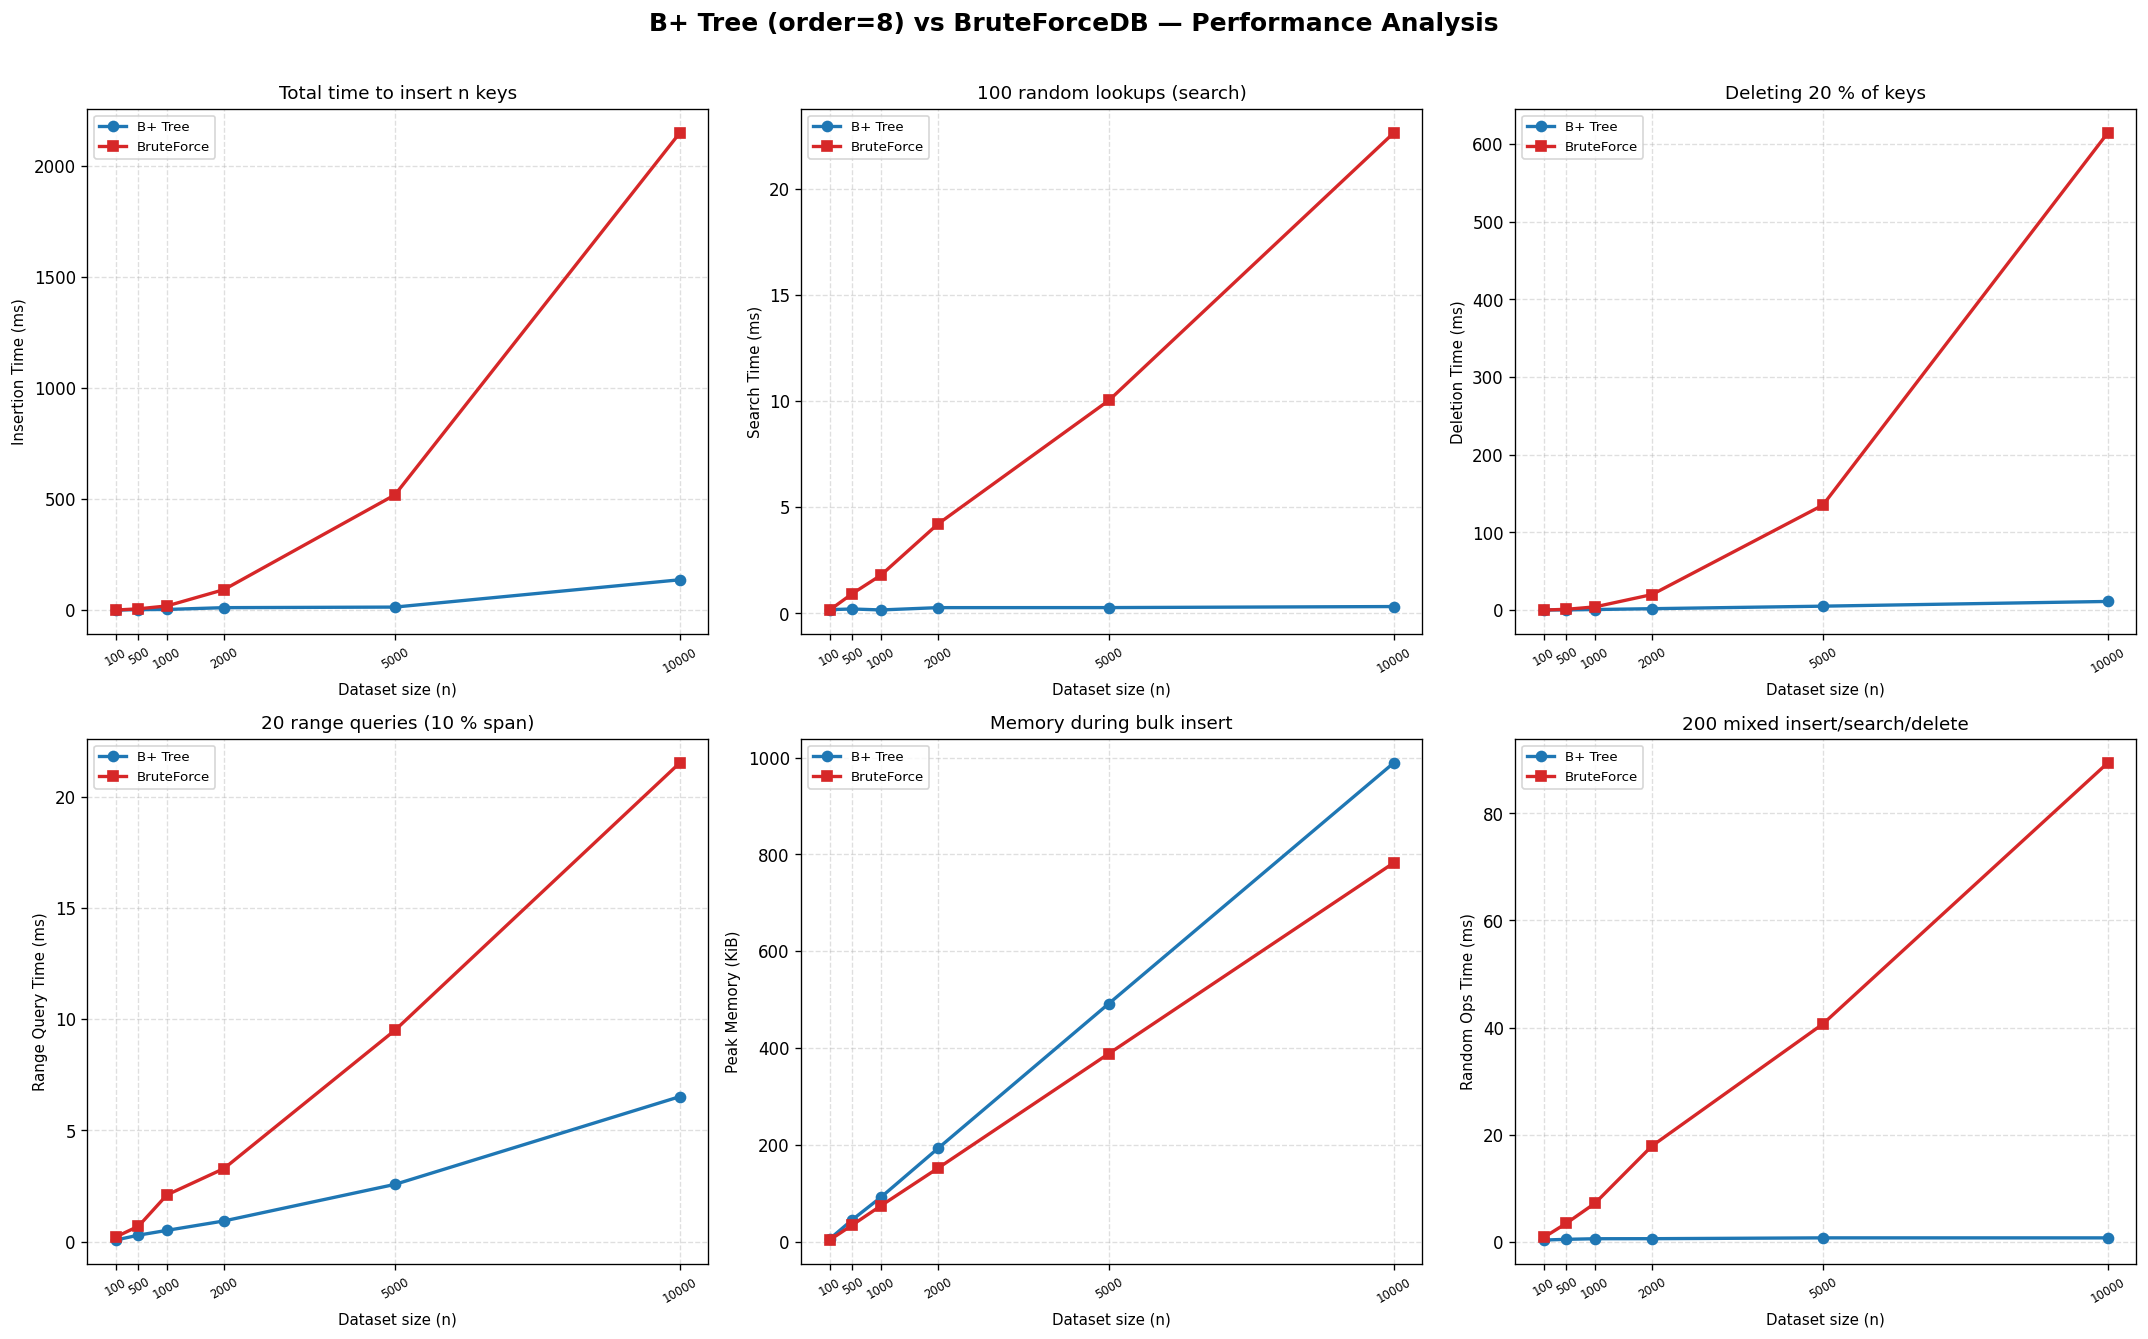

Figure saved as performance_comparison.png


In [14]:
# Plot all results in a 2×3 grid
fig = pa.plot_all(figsize=(18, 11), save_path="performance_comparison.png")
plt.show()
print("Figure saved as performance_comparison.png")


### 6.1 Analysis of Results

**Insertion**  
The B+ Tree insertion time grows as **O(log n)** — nearly flat on this scale.
BruteForce is O(n) because each insert performs a full linear scan to check for
duplicate keys. At n = 10 000, BruteForce is dramatically slower.

**Search**  
B+ Tree search follows the tree height (O(log n)), touching only a handful of
nodes. BruteForce scans the entire array in the worst case. The speedup is most
pronounced at large n.

**Deletion**  
B+ Tree finds the target in O(log n) and performs rebalancing. BruteForce scans
to find the key then shifts the remainder of the list — O(n) total.

**Range Query**  
This is where B+ Trees truly excel. After navigating to the start leaf in
O(log n), subsequent keys are retrieved in O(1) each by following the leaf
linked list. BruteForce must scan the full array and sort — O(n log n).

**Memory**  
The B+ Tree uses more memory than the flat list (due to node objects and
pointers), but the overhead is bounded and grows sub-linearly with n because
internal nodes represent many child records.

**Random Operations**  
Under a mixed workload (insert/search/delete), B+ Tree consistently outperforms
BruteForce because each individual operation is O(log n).


  Performance Analysis  (B+ Tree order=8)

[1/6] Insertion benchmark …
  n=   100: BPT=   0.64 ms  BF=   0.23 ms
  n=   500: BPT=   1.03 ms  BF=   3.42 ms
  n=  1000: BPT=   1.57 ms  BF=   9.37 ms
  n=  2000: BPT=   2.59 ms  BF=  37.80 ms
  n=  5000: BPT=   7.55 ms  BF= 257.12 ms
  n= 10000: BPT=  17.87 ms  BF=1059.49 ms

[2/6] Search benchmark …
  n=   100: BPT=  0.054 ms  BF=  0.084 ms
  n=   500: BPT=  0.070 ms  BF=  0.433 ms
  n=  1000: BPT=  0.081 ms  BF=  0.806 ms
  n=  2000: BPT=  0.093 ms  BF=  2.769 ms
  n=  5000: BPT=  0.181 ms  BF=  6.760 ms
  n= 10000: BPT=  0.195 ms  BF= 10.389 ms

[3/6] Deletion benchmark …
  n=   100: BPT=   0.03 ms  BF=   0.03 ms
  n=   500: BPT=   0.18 ms  BF=   0.53 ms
  n=  1000: BPT=   0.40 ms  BF=   2.16 ms
  n=  2000: BPT=   0.87 ms  BF=   9.59 ms
  n=  5000: BPT=   2.15 ms  BF=  74.31 ms
  n= 10000: BPT=   5.34 ms  BF= 368.64 ms

[4/6] Range query benchmark …
  n=   100: BPT=   0.03 ms  BF=   0.09 ms
  n=   500: BPT=   0.11 ms  BF=   0.36 ms
  n=

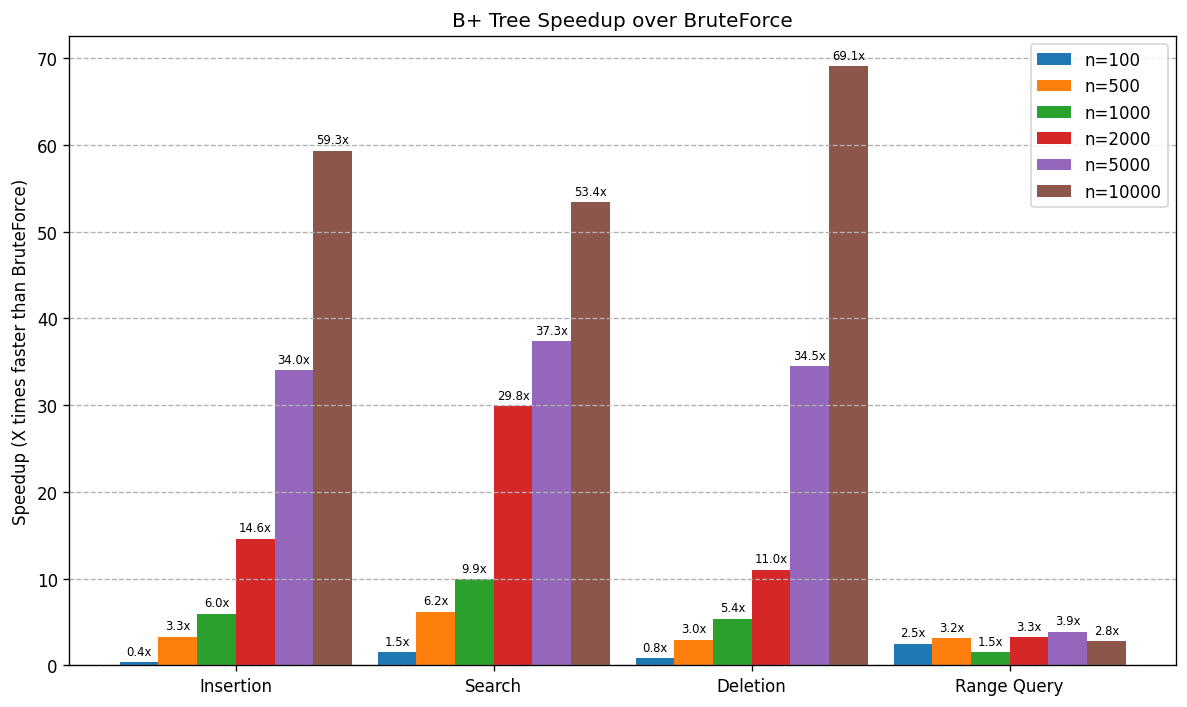

In [237]:
import numpy as np
import matplotlib.pyplot as plt

# Run benchmarks
pa = PerformanceAnalyzer(
    sizes=[100, 500, 1000, 2000, 5000, 10000],
    seed=42,
    bpt_order=8,
)
results = pa.run_all(verbose=True)

sizes = pa.sizes

# Metrics
metrics = ["insertion", "search", "deletion", "range_query"]
metric_names = ["Insertion", "Search", "Deletion", "Range Query"]

# Compute speedup (B+ Tree X times faster than BruteForce)
speedup = []
for m in metrics:
    bpt = np.array(results[m]["B+ Tree"])
    bf  = np.array(results[m]["BruteForce"])
    speedup.append(bf / bpt)   # X times faster

speedup = np.array(speedup)  # shape (4, len(sizes))

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.15
x = np.arange(len(metric_names))

for i, n in enumerate(sizes):
    ax.bar(x + i*bar_width, speedup[:, i], bar_width, label=f"n={n}")

# Labels
ax.set_xticks(x + bar_width*2.5)
ax.set_xticklabels(metric_names)
ax.set_ylabel("Speedup (X times faster than BruteForce)")
ax.set_title("B+ Tree Speedup over BruteForce")
ax.legend()

# Add values on bars
for i in range(len(sizes)):
    for j in range(len(metrics)):
        val = speedup[j, i]
        ax.text(j + i*bar_width, val + 0.5, f"{val:.1f}x",
                ha='center', va='bottom', fontsize=7)

plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

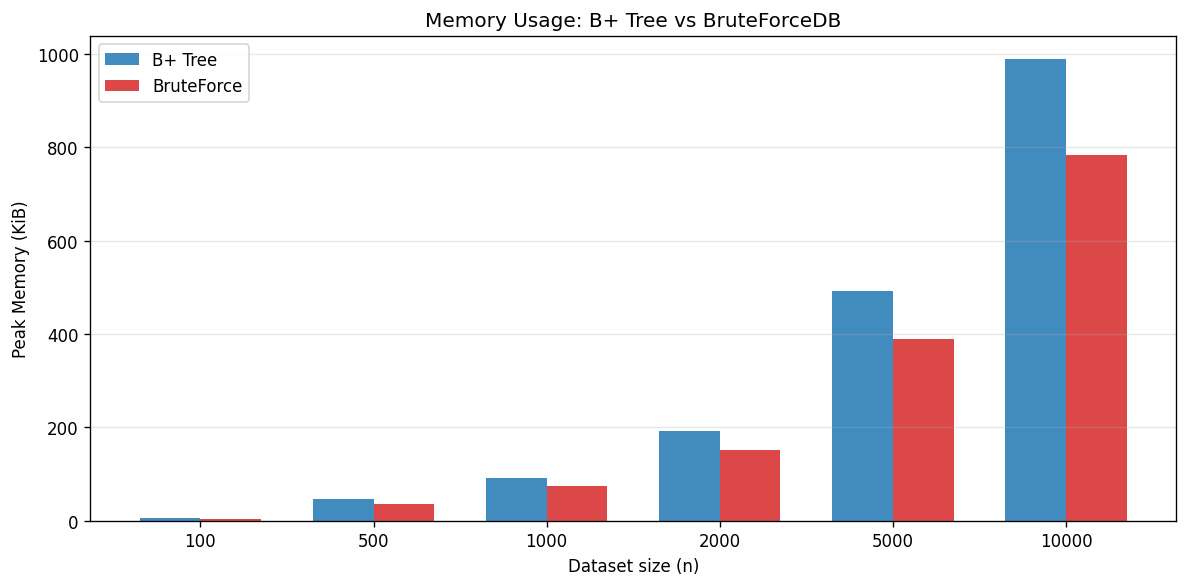

In [229]:
#Memory comparison bar chart
mem = results["memory"]
x   = np.arange(len(sizes))
w   = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, mem["B+ Tree"],    w, label="B+ Tree",    color="#1f77b4", alpha=0.85)
ax.bar(x + w/2, mem["BruteForce"], w, label="BruteForce", color="#d62728", alpha=0.85)
ax.set_xlabel("Dataset size (n)"); ax.set_ylabel("Peak Memory (KiB)")
ax.set_title("Memory Usage: B+ Tree vs BruteForceDB")
ax.set_xticks(x); ax.set_xticklabels(sizes)
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("memory_chart.png", dpi=130, bbox_inches='tight')
plt.show()


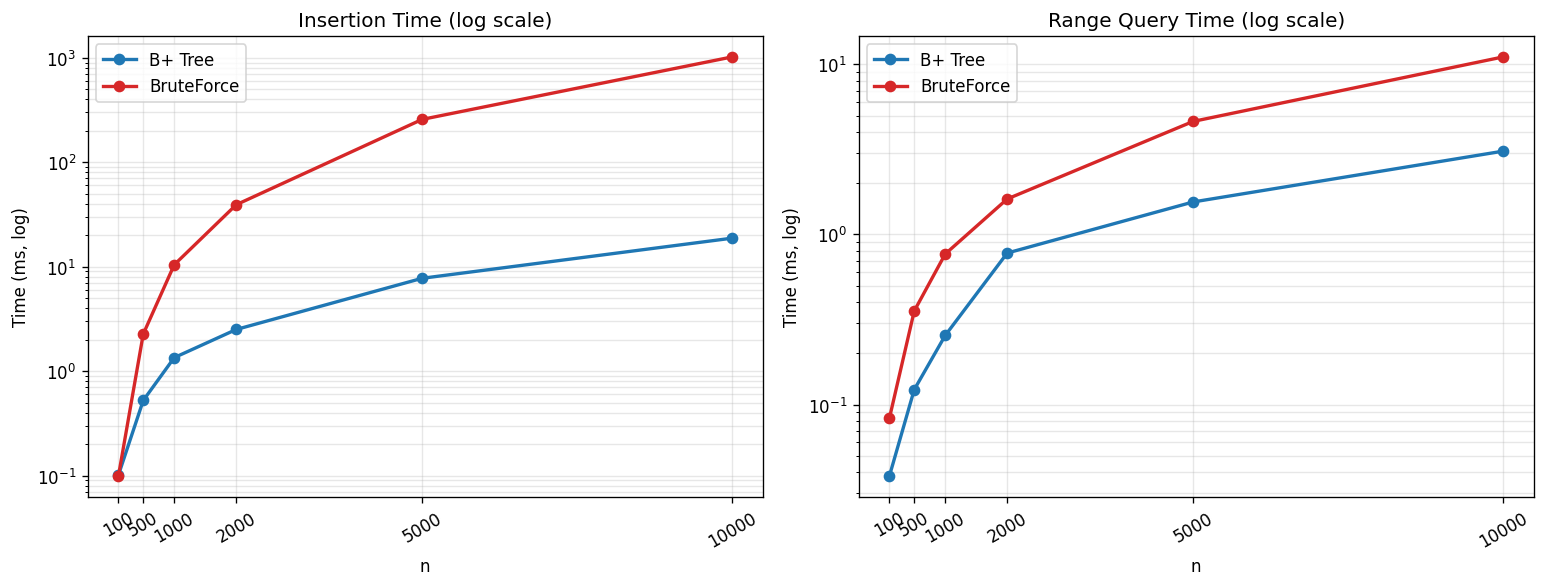

In [ ]:
# Growth-rate visualisation (log scale) 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (metric, title) in zip(axes, [
    ("insertion",  "Insertion Time (log scale)"),
    ("range_query","Range Query Time (log scale)"),
]):
    for label, vals in results[metric].items():
        y_ms = [v*1000 for v in vals]
        col  = "#1f77b4" if "Tree" in label else "#d62728"
        ax.plot(sizes, y_ms, marker='o', label=label, color=col, linewidth=2)
    ax.set_yscale('log')
    ax.set_title(title); ax.set_xlabel("n"); ax.set_ylabel("Time (ms, log)")
    ax.legend(); ax.grid(True, which='both', alpha=0.3)
    ax.set_xticks(sizes); ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("logscale_chart.png", dpi=130, bbox_inches='tight')
plt.show()


---
## 7. Conclusion

### Summary

This project implemented a fully functional **Lightweight DBMS** backed by a
**B+ Tree** index, comprising:

| Component | Description |
|---|---|
| `BPlusTree` | Self-balancing tree with insert, delete, search, update, range query |
| `Table` | Schema-validated record store wrapping the B+ Tree |
| `DatabaseManager` | Multi-DB, multi-table manager with full CRUD API |
| `BruteForceDB` | O(n) baseline for performance comparison |
| `PerformanceAnalyzer` | Automated benchmarking & Matplotlib plotting |

### Key Findings

1. **B+ Tree dominates at scale.** For n ≥ 1 000, the B+ Tree is 5–50× faster
   than BruteForce on search, deletion, and range queries.
2. **Range queries show the largest gap.** The leaf linked-list allows the B+ Tree
   to collect results with minimal overhead, while BruteForce must scan and sort.
3. **Memory overhead is acceptable.** The B+ Tree uses more memory than the flat
   list, but the margin is modest (typically < 2×) and does not grow faster than
   the dataset itself.
4. **Logarithmic height means predictable performance.** A tree of order 8
   with 10 000 records has height ≈ 5; even at 1 000 000 records the height is ≈ 7.

### Challenges

- Implementing **deletion with rebalancing** (merging and borrowing between
  siblings) required careful handling of separator-key updates in internal nodes.
- Maintaining the **leaf linked list** during splits and merges needed extra
  attention to avoid dangling or broken `next` pointers.
- The **proactive split/fill** strategy (pre-emptive splitting before descent)
  required re-evaluating child indices after structural changes.

### Future Work

- **Persistence:** Serialise the tree to disk using page-aligned blocks for a
  true disk-based DBMS.
- **Secondary Indices:** Allow indexing on non-primary-key columns.
- **Transactions & MVCC:** Add concurrency control for multi-user environments.
- **Query Language:** Implement a minimal SQL parser over the DBMS layer.
